# 02 - Variable Construction (local port, corrected)

Stage 2 of the pipeline: build the **target variable** and the **CAMELS explanatory variables** from
the panel produced by `01_DataDownload.ipynb`.

**This notebook runs on the prudential conglomerate panel by default** (`PANEL` in the setup cell).
The target is a threshold on the IF.Data BIS ratio, which is reported per *conglomerate*, so
building the explanatory variables at the same level removes a consolidation mismatch that costs
roughly half the panel its label. Set `PANEL = 'individual'` to reproduce the instructor's bank-level
frame. Rationale, measurements and trade-offs are in
[`CHANGES_AND_WHY.md`](CHANGES_AND_WHY.md), change N1.

Ported from `course_files/code/02_Variable_Construction.ipynb`.

**Corrections applied here.** Each one is itemised, justified and measured in
[`CHANGES_AND_WHY.md`](CHANGES_AND_WHY.md) against the instructor's cell number and original
line, so every one can be traced and raised in class:

| # | Instructor cell | What changed |
|---|---|---|
| C1 | 41 | `interpolate(method='linear')` gains `limit_area='inside'`, because the default silently carries the last observed value forward forever |
| C2 | 45 | a missing `BIS_linear` yields `bis_flag = NaN` (unknown), not `1` (breach) |
| C3 | 45, 53 | the 12-month window and `target` propagate that NaN instead of counting it as a bad |

**Panel changes** from moving to conglomerate level, covered as change N1 in
[`CHANGES_AND_WHY.md`](CHANGES_AND_WHY.md):

| # | Instructor cell | What changed |
|---|---|---|
| D3 | 7 | reads `df_final_congl.parquet`, keyed on `COD_CONGL`, behind a `PANEL` switch |
| D4 | 31, 45 | the explicit default list is read from the instructor's `default_flag.xlsx` and its `ID` resolved onto `ID_COL`; the 12-month window is anchored on the decree date, not on the last filing |

Plumbing differences, which aren't methodological: local `pathlib` paths instead of
`google.colab.drive.mount`; the twelve near-identical `shift()` lines written as loops; the
worked-example queries using `FOCUS_BIG` / `FOCUS_EVENT` instead of hard-coded CNPJs so they resolve
on either panel. Cells marked **CHECK** are diagnostics that don't exist in the instructor's
notebook.

Lecture reference: *Session 4 - Data Preparation and the Target Variable*.

Set up local directories. Run this notebook with this folder as the working directory.

In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

base_dir = pathlib.Path.cwd()
dir_inputs = base_dir / 'Input'
dir_outputs = base_dir / 'Output'

pd.set_option('display.max_rows', 200)
np.random.seed(42)

print(f"Base directory: {base_dir}")

Base directory: C:\Github_offline\Credit Risk Modelling\Python


Import the panel prepared in notebook `01_DataDownload`.

`PANEL` picks the consolidation level. `'conglomerate'` reads `df_final_congl.parquet`, keyed on
`COD_CONGL`, which is the level IF.Data reports capital at and therefore the level the target is
defined at. `'individual'` reads `df_final.parquet`, keyed on `CNPJ`, which is what the instructor's
notebook uses. Everything below works on either.

In [2]:
PANEL = 'conglomerate'          # 'conglomerate' (recommended) or 'individual'

PANEL_SPEC = {'conglomerate': ('df_final_congl.parquet', 'COD_CONGL'),
              'individual': ('df_final.parquet', 'CNPJ')}
parquet_name, ID_COL = PANEL_SPEC[PANEL]

df = pd.read_parquet(dir_outputs / parquet_name)

# One row per (ID_COL, DATA) is what every shift() and interpolate() below assumes.
n_dup = int(df.duplicated([ID_COL, 'DATA']).sum())
assert n_dup == 0, f"{n_dup} duplicate ({ID_COL}, DATA) rows"

print(f"panel  : {PANEL}  ({parquet_name})")
print(f"shape  : {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"({df['DATA'].min()} to {df['DATA'].max()}, {df['DATA'].nunique()} periods)")
print(f"key    : {ID_COL}  ({df[ID_COL].nunique()} distinct, {n_dup} duplicate keys)")

# One large, well-covered institution used throughout as the worked example (Banco do Brasil).
FOCUS_BIG = 0 if PANEL == 'individual' else 'C0080329'
print(f"worked example: {FOCUS_BIG} "
      f"({df.loc[df[ID_COL] == FOCUS_BIG, 'NOME_INSTITUICAO'].iloc[-1]})")

panel  : conglomerate  (df_final_congl.parquet)
shape  : 14,566 rows x 267 columns (201701 to 202603, 111 periods)
key    : COD_CONGL  (230 distinct, 0 duplicate keys)
worked example: C0080329 (BCO DO BRASIL S.A.)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14566 entries, 0 to 14565
Columns: 267 entries, DATA to 99999995
dtypes: float64(261), int64(2), object(4)
memory usage: 29.7+ MB


Example of Tier 1 capital of Banco do Brasil, downloaded from IF.Data

In [4]:
df.query('COD_CONGL == "C0080329"')['Tier_1'].describe()

count    3.700000e+01
mean     1.346404e+11
std      3.443222e+10
min      8.486725e+10
25%      9.638020e+10
50%      1.413528e+11
75%      1.616563e+11
max      1.927940e+11
Name: Tier_1, dtype: float64

Import the COSIF and IF.Data account-name lookups written by notebook 01.

In [5]:
cosif_account_name = pd.read_excel(dir_outputs / 'cosif_account_name.xlsx').iloc[:, 1:]
if_account_name = pd.read_excel(dir_outputs / 'if_account_name.xlsx').iloc[:, 1:]

print(f"COSIF accounts: {cosif_account_name['CONTA'].nunique()}")
if_account_name

COSIF accounts: 1261

,Conta,NomeColuna
0,79647,Tier_1
1,79648,Tier_2
2,79649,Capital
3,79650,CRWA
4,79651,MRWA
5,79656,ORWA
6,79664,BIS
7,79665,RWA


## Target Variable

### Explicit

Bank-failure events, cross-checked against the FGC (Brazil's deposit insurance institution)
special-liquidation register:
<https://www.fgc.org.br/documents/d/asset-library-54291/liquidacoes-regime-especial_082026>

In [6]:
banks = df[['NOME_INSTITUICAO', ID_COL]].drop_duplicates().reset_index(drop=True)
banks.to_excel(dir_outputs / 'bank.xlsx')
print(f"{len(banks)} distinct (institution, {ID_COL}) pairs -> bank.xlsx")
banks.head()

292 distinct (institution, COD_CONGL) pairs -> bank.xlsx


,NOME_INSTITUICAO,COD_CONGL
0,BCO DO BRASIL S.A.,C0080329
1,BRB - BCO DE BRASILIA S.A.,C0080288
2,SANTINVEST S.A. - CFI,C0080446
3,COINVALORES CCVM LTDA.,C0080707
4,CAIXA ECONOMICA FEDERAL,C0080738


Institutions named in the course exercise. NEON is the worked example; the rest are for you to
complete.

On the **individual** panel six of the nine are missing outright. `BANCOS` covers commercial banks
only, and DACASA, BRK, PORTOCRED and WILL are `SOC. DE CREDITO, FINANCIAMENTO E INVESTIMENTO`,
published in the separate `SOCIEDADES` extract (`CHANGES_AND_WHY.md`, open issue O1).

On the **conglomerate** panel most of them come back, because their prudential conglomerate *is* in
the `BLOPRUDENCIAL` extract even when the entity itself isn't a bank. That wasn't the reason for
moving to conglomerate level, but it's a useful side effect. See `CHANGES_AND_WHY.md`, open issue O1.

In [7]:
name_cols = [c for c in ['NOME_INSTITUICAO', 'NOME_CONGL'] if c in df.columns]

for name in ['NEON', 'DOMUS', 'DACASA', 'CHB', 'BRK', 'PORTOCRED',
             'MASTER', 'LETSBANK', 'WILL', 'PLENO']:
    match = False
    for col in name_cols:
        match = match | df[col].str.contains(name, case=False, na=False)
    hit = df[match]
    print(f"--- {name} ---")
    if len(hit):
        print(hit.groupby([ID_COL] + name_cols[-1:])['DATA']
                 .agg(['min', 'max', 'count']).to_string())
    else:
        print("not present in this panel")

--- NEON ---
                                              min     max  count
COD_CONGL NOME_CONGL                                            
C0085702  NEON PAGAMENTOS - PRUDENCIAL     202105  202201      9
          NEON PAGAMENTOS IP - PRUDENCIAL  202202  202603     50
--- DOMUS ---
not present in this panel
--- DACASA ---
                                             min     max  count
COD_CONGL NOME_CONGL                                           
C0081005  DACASA FINANCEIRA - PRUDENCIAL  201701  202001     37
--- CHB ---
not present in this panel
--- BRK ---
                                      min     max  count
COD_CONGL NOME_CONGL                                    
C0080453  BROOKFIELD - PRUDENCIAL  201701  201706      6
--- PORTOCRED ---
not present in this panel
--- MASTER ---
                                        min     max  count
COD_CONGL NOME_CONGL                                      
C0080367  BANCO MASTER - PRUDENCIAL  202011  202506     56
--- LETSBANK ---
      

#### Change D4: the explicit default list comes from `default_flag.xlsx`

IN02 cell 17 points at the FGC (Fundo Garantidor de Créditos) special-regime register, and cells
29-30 set the exercise: read the failures out of it and complete `ind_default` for DOMUS, DACASA,
CHB, BRK, PORTOCRED, MASTER, LETSBANK, WILL and PLENO, with Banco Neon (IN02 cell 31) as the worked
example.

`course_files/code/default_flag.xlsx` is the instructor's own answer to that exercise, and it's the
**ground truth** we use here. Sheet `Planilha1` carries one row per (institution, liquidation) pair:

| column | meaning |
|---|---|
| `ID` | institution key: `CNPJ` for individual/society rows, numeric `COD_CONGL` for prudential rows |
| `LIQUIDATION_DATA` | the decree month, `YYYYMM` |
| `LAST_AVAILABLE_DATA` | the last month that institution filed |
| `DELTA` | months between the two |
| `FORWARD_IND` | `12 - DELTA`, how many of the twelve flag months actually have a panel row |
| `IND_FIRST_FLAG` | `LIQUIDATION_DATA` minus twelve months, the first month carrying the flag |

Sheet `Planilha2` is the worked illustration: an institution liquidated in 201801 whose last filing
is 201712 carries `ind_default = 1` on every month from **201701 to 201712**. So the window is
anchored on the **decree**, not on the last filing, and it runs *backwards*, which is the same "in
breach now, or within the next twelve months" target read the other way round. At date *t* the flag
answers "is this institution in breach now, or will it be within the next twelve months?"

We keep the FGC register below as a **CHECK** rather than dropping it. It's the primary source for
the decree dates, and it disagrees with the spreadsheet on exactly one entry.

In [8]:
# The instructor's default-event answer sheet ships with the course material.
def _find_ref(fname):
    """Course reference file: bundled in Input/reference/ for the standalone handover,
    else taken from the course_files/ checkout one level up."""
    for p in (base_dir / 'Input' / 'reference' / fname,
              base_dir.parent / 'course_files' / 'code' / fname):
        if p.exists():
            return p
    raise FileNotFoundError(fname)

DEFAULT_FLAG_XLSX = _find_ref('default_flag.xlsx')

default_flag = pd.read_excel(DEFAULT_FLAG_XLSX, sheet_name='Planilha1')


def month_index(data):
    # YYYYMM -> a plain month counter, so arithmetic crosses year boundaries correctly
    return (data // 100) * 12 + (data % 100)


def add_months(data, n):
    t = month_index(data) + n - 1
    return (t // 12) * 100 + (t % 12) + 1


# Re-derive the computed columns rather than trust them, so a typo in the sheet surfaces here.
chk = default_flag.assign(
    delta_calc=month_index(default_flag['LIQUIDATION_DATA'])
    - month_index(default_flag['LAST_AVAILABLE_DATA']),
    first_calc=[add_months(d, -12) for d in default_flag['LIQUIDATION_DATA']])
chk['forward_calc'] = 12 - chk['delta_calc']

for col, calc in [('DELTA', 'delta_calc'), ('FORWARD_IND', 'forward_calc'),
                  ('IND_FIRST_FLAG', 'first_calc')]:
    bad = chk.loc[chk[col] != chk[calc], ['ID', 'BANK', col, calc]]
    assert not len(bad), f"{col} disagrees with its own definition:\n{bad}"

print(f"{len(default_flag)} rows, "
      f"{default_flag.groupby(['BANK', 'LIQUIDATION_DATA']).ngroups} distinct liquidation events, "
      f"{default_flag['LIQUIDATION_DATA'].min()} to {default_flag['LIQUIDATION_DATA'].max()}")
print("internal arithmetic verified: IND_FIRST_FLAG = LIQUIDATION_DATA - 12 months, "
      "DELTA = LIQUIDATION_DATA - LAST_AVAILABLE_DATA, FORWARD_IND = 12 - DELTA")
default_flag

18 rows, 10 distinct liquidation events, 201805 to 202602
internal arithmetic verified: IND_FIRST_FLAG = LIQUIDATION_DATA - 12 months, DELTA = LIQUIDATION_DATA - LAST_AVAILABLE_DATA, FORWARD_IND = 12 - DELTA


,ID,BANK,LIQUIDATION_DATA,LAST_AVAILABLE_DATA,DELTA,FORWARD_IND,IND_FIRST_FLAG
0,253448,NEON,201805,201804,1,11,201705
1,10372647,DOMUS,201805,201804,1,11,201705
2,81005,DACASA,202002,202001,1,11,201902
3,27406222,DACASA,202002,202001,1,11,201902
4,10694628,CHB,202103,202102,1,11,202003
5,12865507,BRK,202302,202301,1,11,202202
6,1800019,PORTOCRED,202302,202212,2,10,202202
7,80367,MASTER,202511,202506,5,7,202411
8,9526594,MASTER,202511,202507,4,8,202411
9,33884941,MASTER,202511,202507,4,8,202411


#### Mapping the spreadsheet's key onto this panel

`ID` is the identifier of the instructor's **stacked** panel (`01_DataDownload_student_v2`), where
individual and society rows are keyed by `CNPJ` and prudential rows by the last five digits of
`COD_CONGL`. This pipeline models the prudential conglomerate panel only, so we resolve every `ID`
by trying both readings:

1. `ID == CNPJ`. The conglomerate panel's `CNPJ` column carries the conglomerate's *lead*
   institution, so this picks out only the periods that institution led it. That matters, because
   `C0084600` was Avista, then Will, and is now REAG.
2. `ID == int(COD_CONGL[-5:])`, the prudential reading: `80367` -> `C0080367`.

**We flag rows, never keys**, so an identifier that changes hands mid-panel can't drag the flag onto
a different institution. A CNPJ match that's stale by more than `MAX_GAP_MONTHS` gets rejected
outright: CNPJ `33884941` (Banco Master Múltiplo) appears here only for 201701-201803 as the lead of
the *Banif* conglomerate, and without the guard its 2025 decree would be pinned onto a 2018 Banif
row.

`LAST_AVAILABLE_DATA` is computed on the instructor's stacked panel, so it reproduces exactly for
the prudential-keyed entries and differs for those whose rows come from the `SOCIEDADES` extract we
don't download (`CHANGES_AND_WHY.md`, open issue O1). The table below reports that agreement per entry
rather than assuming it.

In [9]:
MAX_GAP_MONTHS = 12

congl_key = (df['COD_CONGL'].str[-5:].astype(int) if 'COD_CONGL' in df.columns
             else pd.Series(-1, index=df.index))

rows, entity_mask = [], {}
for i, e in default_flag.iterrows():
    liq = int(e['LIQUIDATION_DATA'])
    by_cnpj, by_congl = df['CNPJ'] == e['ID'], congl_key == e['ID']
    mask, how = ((by_cnpj, 'CNPJ') if by_cnpj.any() else
                 (by_congl, 'COD_CONGL') if by_congl.any() else (None, '-'))

    rec = {'ID': e['ID'], 'BANK': e['BANK'], 'LIQUIDATION_DATA': liq, 'matched_on': how,
           'panel_last': pd.NA, 'last_xlsx': int(e['LAST_AVAILABLE_DATA']),
           'gap_months': pd.NA, 'status': 'not in this panel'}

    if mask is not None:
        prior = df.loc[mask & (df['DATA'] <= liq), 'DATA']
        if not len(prior):
            rec['status'] = 'no filing on or before the decree'
        else:
            gap = month_index(liq) - month_index(int(prior.max()))
            rec['panel_last'], rec['gap_months'] = int(prior.max()), gap
            if gap > MAX_GAP_MONTHS:
                rec['status'] = f'rejected: stale by {gap}m'
            else:
                rec['status'] = 'matched'
                entity_mask[i] = mask
    rows.append(rec)

match_table = pd.DataFrame(rows)
match_table['last_agrees'] = match_table['panel_last'] == match_table['last_xlsx']
print(match_table.to_string(index=False))
print()
print(f"{len(entity_mask)} of {len(default_flag)} spreadsheet rows resolve onto this panel; "
      f"{int(match_table['last_agrees'].sum())} reproduce LAST_AVAILABLE_DATA exactly")

      ID      BANK  LIQUIDATION_DATA matched_on panel_last  last_xlsx gap_months                 status  last_agrees
  253448      NEON            201805          -       <NA>     201804       <NA>      not in this panel        False
10372647     DOMUS            201805          -       <NA>     201804       <NA>      not in this panel        False
   81005    DACASA            202002  COD_CONGL     202001     202001          1                matched         True
27406222    DACASA            202002       CNPJ     202001     202001          1                matched         True
10694628       CHB            202103          -       <NA>     202102       <NA>      not in this panel        False
12865507       BRK            202302          -       <NA>     202301       <NA>      not in this panel        False
 1800019 PORTOCRED            202302          -       <NA>     202212       <NA>      not in this panel        False
   80367    MASTER            202511  COD_CONGL     202506     2

#### The flag itself

Two columns come out of this:

- `ind_default_12m`, **the target**. `1` on every panel row of a matched institution whose `DATA`
  falls in `[IND_FIRST_FLAG, LIQUIDATION_DATA - 1]`, so the twelve months preceding the decree.
  That's `Planilha2`'s window verbatim.
- `ind_default`, the point event. `1` on the single last month the institution filed on or before
  the decree. It isn't the target; it's what the staircase below and the instructor's `shift()`
  construction are built on, and it equals `LAST_AVAILABLE_DATA` wherever the two panels agree.

We flag on a boolean row mask rather than by merging, so `df`'s row order and index stay untouched.

In [10]:
df['ind_default'] = 0
df['ind_default_12m'] = 0

flagged = []
for i, e in default_flag.iterrows():
    if i not in entity_mask:
        continue
    mask, liq = entity_mask[i], int(e['LIQUIDATION_DATA'])

    window = mask & df['DATA'].between(int(e['IND_FIRST_FLAG']), add_months(liq, -1))
    df.loc[window, 'ind_default_12m'] = 1

    event_row = df.loc[mask & (df['DATA'] <= liq), 'DATA'].idxmax()
    df.loc[[event_row], 'ind_default'] = 1

    flagged.append({'ID': e['ID'], 'BANK': e['BANK'],
                    'window': f"{int(e['IND_FIRST_FLAG'])}-{add_months(liq, -1)}",
                    'FORWARD_IND': int(e['FORWARD_IND']), 'rows_flagged': int(window.sum()),
                    'event_period': int(df.at[event_row, 'DATA']),
                    ID_COL: df.at[event_row, ID_COL]})

print(pd.DataFrame(flagged).to_string(index=False))
print()
print(f"ind_default     == 1: {int(df['ind_default'].sum())} rows (point events)")
print(f"ind_default_12m == 1: {int(df['ind_default_12m'].sum())} rows")

# the flagged institution with the longest history, used as the worked example below
hit_keys = df.loc[df['ind_default_12m'] == 1, ID_COL].unique()
FOCUS_EVENT = df.loc[df[ID_COL].isin(hit_keys), ID_COL].value_counts().idxmax()
print()
print(f"worked default example: {FOCUS_EVENT} "
      f"({df.loc[df[ID_COL] == FOCUS_EVENT, 'NOME_INSTITUICAO'].iloc[-1]})")

      ID   BANK        window  FORWARD_IND  rows_flagged  event_period COD_CONGL
   81005 DACASA 201902-202001           11            12        202001  C0081005
27406222 DACASA 201902-202001           11            12        202001  C0081005
   80367 MASTER 202411-202510            7             8        202506  C0080367
33923798 MASTER 202411-202510            7             8        202506  C0080367
   80415  PLENO 202502-202601            8             2        202510  C0080415
   88668  PLENO 202502-202601            6             1        202508  C0088668
61024352  PLENO 202502-202601           11             3        202510  C0080415



ind_default     == 1: 4 rows (point events)
ind_default_12m == 1: 23 rows

worked default example: C0080367 (BANCO MASTER - EM LIQUIDAÇÃO EXTRAJ)


The staircase from Session 4, slide 12. The flag is already 1 twelve months before the event.

In [11]:
df[(df[ID_COL] == FOCUS_EVENT) & (df['ind_default_12m'] == 1)][
    ['DATA', ID_COL, 'CNPJ', 'NOME_INSTITUICAO', 'ind_default', 'ind_default_12m']]

,DATA,COD_CONGL,CNPJ,NOME_INSTITUICAO,ind_default,ind_default_12m
11925,202411,C0080367,33923798,BANCO MASTER,0,1
12075,202412,C0080367,33923798,BANCO MASTER,0,1
12225,202501,C0080367,33923798,BANCO MASTER,0,1
12381,202502,C0080367,33923798,BANCO MASTER,0,1
12540,202503,C0080367,33923798,BANCO MASTER,0,1
12700,202504,C0080367,33923798,BANCO MASTER - EM LIQUIDAÇÃO EXTRAJ,0,1
12862,202505,C0080367,33923798,BANCO MASTER - EM LIQUIDAÇÃO EXTRAJ,0,1
13025,202506,C0080367,33923798,BANCO MASTER - EM LIQUIDAÇÃO EXTRAJ,1,1


**CHECK**: the spreadsheet against the FGC register.

The register is a one-page PDF listing 45 institutions placed under `Intervenção` or
`Liquidação Extrajudicial` between 1996 and 2026, with the **decretação** date for each:

<https://www.fgc.org.br/documents/d/asset-library-54291/liquidacoes-regime-especial_082026>

It's the primary source for the dates the spreadsheet encodes, so it's worth parsing and comparing.
Matching here is by name, which is fine for a diagnostic but never for the target itself, because
`BRK S.A. - CFI` and `BRKB DTVM S.A.` (Brookfield) share a prefix and are unrelated, and a substring
match on "NEON" hits `NEON PAGAMENTOS`, the successor payment institution that never failed.

The PDF downloads once into `Input/FGC/` and is **not** committed, since it carries an FGC
restricted-circulation notice and `Input/` is gitignored. The cell degrades to a warning if it's
absent, so the notebook still runs without it.

In [12]:
import re
import urllib.request

FGC_URL = ("https://www.fgc.org.br/documents/d/asset-library-54291/"
           "liquidacoes-regime-especial_082026")
fgc_pdf = dir_inputs / 'FGC' / 'liquidacoes-regime-especial.pdf'
FGC_ROW = re.compile(r'^(?P<instituicao>.+?)\s(?P<decretacao>\d{2}\.\d{2}\.\d{4})\s'
                     r'(?P<tipo>Interven\S+|Liquida\S+\s+Extrajudicial)(?P<resto>.*)$')

fgc = None
try:
    import pypdf
    if not fgc_pdf.exists():                      # never re-download what is already on disk
        fgc_pdf.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(FGC_URL, fgc_pdf)
        print(f"downloaded {fgc_pdf.name}")
    else:
        print(f"using cached {fgc_pdf.name}")

    records = []
    for line in pypdf.PdfReader(fgc_pdf).pages[0].extract_text().split('\n'):
        m = FGC_ROW.match(line.strip())
        if m:
            d = m.group('decretacao')
            records.append({'instituicao': m.group('instituicao').strip(), 'decretacao': d,
                            'DATA_decretacao': int(d[6:10] + d[3:5]),
                            'tipo_regime': m.group('tipo').strip()})
    fgc = pd.DataFrame(records).sort_values('DATA_decretacao').reset_index(drop=True)
    fgc.to_excel(dir_outputs / 'fgc_regime_especial.xlsx')
    print(f"parsed {len(fgc)} register entries, {fgc['DATA_decretacao'].min()} to "
          f"{fgc['DATA_decretacao'].max()}")
except Exception as exc:                          # diagnostic only - never blocks the pipeline
    print(f"FGC register unavailable ({type(exc).__name__}: {exc}) - cross-check skipped")

using cached liquidacoes-regime-especial.pdf


parsed 45 register entries, 199603 to 202601


In [13]:
if fgc is not None:
    # the register's own printed name for each bank in the spreadsheet
    NAME_IN_REGISTER = {'NEON': 'Banco Neon S.A.', 'DOMUS': 'Domus Cia Hipotecária',
                        'DACASA': 'Dacasa Financeira S/A SCFI', 'CHB': 'CHB - Companhia Hipotecária',
                        'BRK': 'BRK S.A. - CFI', 'PORTOCRED': 'Portocred S.A.- CFI',
                        'PLENO': 'Banco Pleno S.A.', 'MASTER': 'Banco Master S.A.',
                        'LETSBANK': 'Banco Letsbank S.A.', 'WILL': 'Will Financeira S.A. - CFI'}

    cmp_reg = (default_flag[['BANK', 'LIQUIDATION_DATA']].drop_duplicates()
               .assign(instituicao=lambda d: d['BANK'].map(NAME_IN_REGISTER))
               .merge(fgc[['instituicao', 'decretacao', 'DATA_decretacao']],
                      on='instituicao', how='left'))
    cmp_reg['agrees'] = cmp_reg['LIQUIDATION_DATA'] == cmp_reg['DATA_decretacao']
    print(cmp_reg.to_string(index=False))

    off = cmp_reg[~cmp_reg['agrees']]
    print()
    print(f"{int(cmp_reg['agrees'].sum())} of {len(cmp_reg)} liquidation dates agree "
          "with the register")
    if len(off):
        print("DISAGREEMENT - the spreadsheet is ground truth here, the register is recorded:")
        print(off[['BANK', 'LIQUIDATION_DATA', 'decretacao', 'DATA_decretacao']]
              .to_string(index=False))

     BANK  LIQUIDATION_DATA                 instituicao decretacao  DATA_decretacao  agrees
     NEON            201805             Banco Neon S.A. 04.05.2018           201805    True
    DOMUS            201805       Domus Cia Hipotecária 22.05.2018           201805    True
   DACASA            202002  Dacasa Financeira S/A SCFI 13.02.2020           202002    True
      CHB            202103 CHB - Companhia Hipotecária 11.03.2021           202103    True
      BRK            202302              BRK S.A. - CFI 15.02.2023           202302    True
PORTOCRED            202302         Portocred S.A.- CFI 15.02.2023           202302    True
   MASTER            202511           Banco Master S.A. 18.11.2025           202511    True
 LETSBANK            202511         Banco Letsbank S.A. 18.11.2025           202511    True
     WILL            202601  Will Financeira S.A. - CFI 21.01.2026           202601    True
    PLENO            202602            Banco Pleno S.A. 18.02.2025           202

**CHECK**: the spreadsheet against BCB's own registry marker.

When BCB puts an institution into special liquidation it eventually renames it
`… - EM LIQUIDAÇÃO EXTRAJUDICIAL`, and that name travels in COSIF's `NOME_INSTITUICAO`. It's a
useful third source, and it also shows why the marker can't date an event:

- **The marker's date is a publication artifact.** Banco Master carries it from 202504, seven months
  before its 18.11.2025 decree, because BCB regenerated the 202504-onward COSIF vintages after the
  liquidation and stamped the then-current name on them. It tells you *that* an institution failed,
  never *when*.
- **The populations differ.** The marker also catches payment institutions and DTVMs. Anything it
  finds that the spreadsheet doesn't list is a genuine special regime with **no date available
  here**, so we deliberately leave it out of the target rather than dating it by guesswork.

In [14]:
marked = df[df['NOME_INSTITUICAO'].str.contains('LIQUIDA', case=False, na=False)]
group_keys = list(dict.fromkeys([ID_COL, 'CNPJ', 'NOME_INSTITUICAO']))
marker_table = (marked.groupby(group_keys, as_index=False)['DATA'].min()
                      .rename(columns={'DATA': 'first_marked_period'}))

flag_ids = set(default_flag['ID'])
marker_congl = (marker_table[ID_COL].astype(str).str[-5:].str.lstrip('0')
                .replace('', '-1').astype(int))
marker_table['in_default_flag'] = (marker_table['CNPJ'].isin(flag_ids)
                                   | marker_congl.isin(flag_ids))

print("Institutions BCB marks as in extrajudicial liquidation:")
print(marker_table.to_string(index=False))

only_marker = marker_table.query('not in_default_flag')
print()
print(f"{len(only_marker)} marked by BCB but absent from default_flag.xlsx -> not in the target")

Institutions BCB marks as in extrajudicial liquidation:
COD_CONGL     CNPJ                    NOME_INSTITUICAO  first_marked_period  in_default_flag
 C0080367 33923798 BANCO MASTER - EM LIQUIDAÇÃO EXTRAJ               202504             True
 C0080415 61024352 BM PLENO S.A. - EM LIQUIDAÇÃO EXTRA               202509             True
 C0085111 34829992 CBSF DTVM -EM LIQUIDAÇÃO EXTRAJUDIC               202504            False
 C0087810 17887874 ENTREPAY IP S.A. - EM LIQUIDAÇÃO EX               202504            False
 C0088668 61024352 BM PLENO S.A. - EM LIQUIDAÇÃO EXTRA               202508             True

2 marked by BCB but absent from default_flag.xlsx -> not in the target


**CHECK**: the decree-anchored window against the instructor's `shift()` construction.

IN02 cell 45 builds the flag by shifting the point event backwards: `tp1` is today and
`tp2`...`tp12` are `shift(-1)`...`shift(-11)`, so the window is today plus the next eleven months.
That anchors the twelve months on the **last filing** instead of on the decree, and the two coincide
only where `DELTA == 1`. Where an institution stopped filing several months before the decree, like
Master (`DELTA = 5`) or Pleno (`DELTA = 4`), the shift version reaches `DELTA - 1` months further
back than `IND_FIRST_FLAG` allows, labelling months as "about to fail" that were still more than a
year out.

`shift()` also moves by one *row* rather than one month, which is only the same thing where an
institution's series has no calendar gaps. Both effects are measured below.

In [15]:
order = df.sort_values([ID_COL, 'DATA'])

shift_12m = df['ind_default'].copy()
for k in range(1, 12):
    shift_12m |= order.groupby(ID_COL)['ind_default'].shift(-k).fillna(0).astype(int)

diff = df.loc[shift_12m != df['ind_default_12m'],
              ['DATA', ID_COL, 'NOME_INSTITUICAO', 'ind_default_12m']].assign(shift_12m=1)
print(f"shift() construction : {int(shift_12m.sum())} rows")
print(f"decree-anchored      : {int(df['ind_default_12m'].sum())} rows")
print(f"rows that differ     : {len(diff)}")
print(diff.to_string(index=False))

steps = order.groupby(ID_COL)['DATA'].apply(lambda s: month_index(s).diff().dropna())
n_gap = int((steps > 1).sum())
print()
print(f"Row-to-row month steps longer than one month: {n_gap} of {len(steps):,} "
      f"({n_gap / len(steps):.3%}) -> shift(-n) is n months ahead for all but these.")

shift() construction : 37 rows
decree-anchored      : 23 rows
rows that differ     : 14
  DATA COD_CONGL NOME_INSTITUICAO  ind_default_12m  shift_12m
202306  C0080415     BANCO VOITER                0          1
202307  C0080415     BANCO VOITER                0          1
202308  C0080415     BANCO VOITER                0          1
202309  C0080415     BANCO VOITER                0          1
202310  C0080415     BANCO VOITER                0          1
202311  C0080415     BANCO VOITER                0          1
202312  C0080415     BANCO VOITER                0          1
202401  C0080415     BANCO VOITER                0          1
202402  C0080415     BANCO VOITER                0          1
202403  C0080415     BANCO VOITER                0          1
202407  C0080367     BANCO MASTER                0          1
202408  C0080367     BANCO MASTER                0          1
202409  C0080367     BANCO MASTER                0          1
202410  C0080367     BANCO MASTER           

### Implicit, Proxy 1: the BIS ratio

IF.Data is quarterly while COSIF is monthly, so capital and RWA are only observed every third month.
Session 4 fills the two intervening months by linear interpolation *within each institution* rather
than dropping them.

In [16]:
df[df[ID_COL] == FOCUS_BIG][['DATA', 'NOME_INSTITUICAO', 'BIS', 'Capital', 'RWA']].head(15)

,DATA,NOME_INSTITUICAO,BIS,Capital,RWA
0,201701,BCO DO BRASIL S.A.,NaN,NaN,NaN
109,201702,BCO DO BRASIL S.A.,NaN,NaN,NaN
218,201703,BCO DO BRASIL S.A.,0.181451,1.240494e+11,6.836515e+11
327,201704,BCO DO BRASIL S.A.,NaN,NaN,NaN
436,201705,BCO DO BRASIL S.A.,NaN,NaN,NaN
546,201706,BCO DO BRASIL S.A.,0.180104,1.270476e+11,7.054125e+11
657,201707,BCO DO BRASIL S.A.,NaN,NaN,NaN
765,201708,BCO DO BRASIL S.A.,NaN,NaN,NaN
873,201709,BCO DO BRASIL S.A.,0.191455,1.291524e+11,6.745846e+11
980,201710,BCO DO BRASIL S.A.,NaN,NaN,NaN


#### Correction C1: interpolation must not extrapolate

Session 4 slide 24 states that `interpolate()` "never extrapolates" at the start or end of a series.
**It does.** `Series.interpolate(method='linear')` defaults to `limit_direction='forward'`, so every
trailing `NaN` after an institution's last observation gets filled by carrying that last value
forward, indefinitely.

The instructor's cell 41 uses the bare default. `limit_area='inside'` restricts the fill to gaps that
sit *between* two real observations, which is the behaviour the slide describes. The next cell
measures what the default was inventing.

In [17]:
for source, target_col in [('Capital', 'Capital_linear'),
                           ('Tier_1', 'Tier1_linear'),
                           ('Tier_2', 'Tier2_linear'),
                           ('RWA', 'RWA_linear'),
                           ('CRWA', 'CRWA_linear')]:
    # groupby().apply() returns a Series indexed by (CNPJ, original row label); reset_index(level=0)
    # drops the group level so it lines back up with df's index. Verified on pandas 2.3.3.
    interpolated = (df.sort_values([ID_COL, 'DATA'])
                      .groupby(ID_COL)[source]
                      .apply(lambda group: group.interpolate(method='linear',
                                                             limit_area='inside')))
    df[target_col] = interpolated.reset_index(level=0, drop=True)


def BIS_linear(row):
    if pd.isnull(row['Capital_linear']):
        return np.nan
    elif row['Capital_linear'] == 0:
        return 0
    else:
        return row['Capital_linear'] / row['RWA_linear']


df['BIS_linear'] = df[['Capital_linear', 'RWA_linear']].apply(BIS_linear, axis=1)
df['BIS_linear'] = df['BIS_linear'] * 100   # percent, to match the 10.5 / 9.25 CMN thresholds

print("Missing rate before -> after interpolation:")
for raw, filled in [('Capital', 'Capital_linear'), ('RWA', 'RWA_linear'),
                    ('CRWA', 'CRWA_linear'), ('BIS', 'BIS_linear')]:
    print(f"  {raw:8s} {df[raw].isna().mean():6.1%}  ->  {filled:16s} {df[filled].isna().mean():6.1%}")

Missing rate before -> after interpolation:
  Capital   68.4%  ->  Capital_linear     7.4%
  RWA       68.4%  ->  RWA_linear         7.4%
  CRWA      79.9%  ->  CRWA_linear       41.4%
  BIS       68.4%  ->  BIS_linear         7.4%


**CHECK C1**: how many values the instructor's default would have invented.

`CRWA` is the worst case. IF.Data stops publishing it after **202306**, so the forward fill freezes
each institution's June-2023 credit RWA and carries it through 202603, up to 33 consecutive
fabricated months feeding straight into `A02`.

In [18]:
order = df.sort_values([ID_COL, 'DATA'])
print(f"{'series':10s} {'filled (inside)':>16s} {'filled (default)':>17s} {'invented':>10s}")
for source in ['Capital', 'Tier_1', 'Tier_2', 'RWA', 'CRWA']:
    fwd = order.groupby(ID_COL)[source].apply(
        lambda g: g.interpolate(method='linear')).reset_index(level=0, drop=True)
    ins = order.groupby(ID_COL)[source].apply(
        lambda g: g.interpolate(method='linear', limit_area='inside')).reset_index(level=0, drop=True)
    print(f"{source:10s} {int(ins.notna().sum()):16,} {int(fwd.notna().sum()):17,} "
          f"{int((fwd.notna() & ins.isna()).sum()):10,}")

last_crwa = int(df.loc[df['CRWA'].notna(), 'DATA'].max())
print(f"\nLast reporting period with any real CRWA: {last_crwa}")
window = (df[ID_COL] == FOCUS_BIG) & df['DATA'].between(202303, 202312)
print(df[window][['DATA', 'CRWA', 'CRWA_linear', 'RWA', 'RWA_linear']].to_string(index=False))

series      filled (inside)  filled (default)   invented
Capital              13,485            13,630        145
Tier_1               12,655            12,753         98
Tier_2               12,651            12,752        101
RWA                  13,485            13,630        145


CRWA                  8,531            12,380      3,849



Last reporting period with any real CRWA: 202306
  DATA         CRWA  CRWA_linear          RWA   RWA_linear
202303 9.362033e+11 9.362033e+11 1.107213e+12 1.107213e+12
202304          NaN 9.386347e+11          NaN 1.107912e+12
202305          NaN 9.410660e+11          NaN 1.108611e+12
202306 9.434974e+11 9.434974e+11 1.109310e+12 1.109310e+12
202307          NaN          NaN          NaN 1.107540e+12
202308          NaN          NaN          NaN 1.105770e+12
202309          NaN          NaN 1.104001e+12 1.104001e+12
202310          NaN          NaN          NaN 1.110918e+12
202311          NaN          NaN          NaN 1.117836e+12
202312          NaN          NaN 1.124754e+12 1.124754e+12


In [19]:
df[df[ID_COL] == FOCUS_BIG][['DATA', 'NOME_INSTITUICAO', 'BIS', 'BIS_linear',
                              'RWA', 'RWA_linear', 'Capital', 'Capital_linear']].head(15)

,DATA,NOME_INSTITUICAO,BIS,BIS_linear,RWA,RWA_linear,Capital,Capital_linear
0,201701,BCO DO BRASIL S.A.,NaN,NaN,NaN,NaN,NaN,NaN
109,201702,BCO DO BRASIL S.A.,NaN,NaN,NaN,NaN,NaN,NaN
218,201703,BCO DO BRASIL S.A.,0.181451,18.145116,6.836515e+11,6.836515e+11,1.240494e+11,1.240494e+11
327,201704,BCO DO BRASIL S.A.,NaN,18.099268,NaN,6.909052e+11,NaN,1.250488e+11
436,201705,BCO DO BRASIL S.A.,NaN,18.054373,NaN,6.981588e+11,NaN,1.260482e+11
546,201706,BCO DO BRASIL S.A.,0.180104,18.010401,7.054125e+11,7.054125e+11,1.270476e+11,1.270476e+11
657,201707,BCO DO BRASIL S.A.,NaN,18.377571,NaN,6.951365e+11,NaN,1.277492e+11
765,201708,BCO DO BRASIL S.A.,NaN,18.755760,NaN,6.848605e+11,NaN,1.284508e+11
873,201709,BCO DO BRASIL S.A.,0.191455,19.145470,6.745846e+11,6.745846e+11,1.291524e+11,1.291524e+11
980,201710,BCO DO BRASIL S.A.,NaN,19.313610,NaN,6.796868e+11,NaN,1.312721e+11


#### Corrections C2 and C3: "no data" is not "in breach"

The instructor's `bis_flag` (cell 45) ends with

```python
elif (pd.isnull(row['BIS_linear'])==True):
    return 1
```

Slide 17 defends this as conservative. In this panel it isn't a rare fallback: institutions outside
a prudential conglomerate have **no IF.Data row at all**, so the branch fires for about half the
panel permanently and `P(target=1 | BIS_linear missing)` comes out at exactly `1.0000`. The label
then *is* the missingness indicator, and every IF.Data-derived explanatory variable predicts it for
free.

Here an unobservable capital position yields `NaN`, meaning unknown, and the window and the final
`target` propagate it, so those rows are simply **unlabelled** rather than labelled bad. We compute
both variants below so the difference is measurable.

The threshold ladder itself is unchanged: six CMN 4553 / 4783 eras, exactly as Session 4 slide 15.

In [20]:
THRESHOLDS = [(201512, 11.0),     # pre-Basel III phase-in baseline
               (202003, 10.5),     # conservation buffer fully phased in
               (202103, 9.25),     # COVID-19 relief
               (202109, 9.625),    # phase-out step 1
               (202203, 10.0),     # phase-out step 2
               (999912, 10.5)]     # full return to the pre-pandemic requirement


def minimum_bis(data):
    for last_period, minimum in THRESHOLDS:
        if data <= last_period:
            return minimum


def bis_flag(row):
    if pd.isnull(row['BIS_linear']):
        return np.nan                      # C2: unknown, not a breach
    return float(row['BIS_linear'] < minimum_bis(row['DATA']))


df['bis_flag'] = df[['DATA', 'BIS_linear']].apply(bis_flag, axis=1)


def bis_flag_course(row):
    # The instructor's *current* rule, ported from the snippet he circulated: a missing BIS is
    # still a breach, but only where the institution belongs to a conglomerate and DATA >= 201703.
    if pd.notnull(row['BIS_linear']):
        return float(row['BIS_linear'] < minimum_bis(row['DATA']))
    if pd.notnull(row['COD_CONGL']) and row['DATA'] >= 201703:
        return 1.0
    return 0.0


df['bis_flag_course'] = df[['DATA', 'BIS_linear', 'COD_CONGL']].apply(bis_flag_course, axis=1)

print(f"bis_flag == 1 (corrected) : {int((df['bis_flag'] == 1).sum()):,}")
print(f"bis_flag is NaN (unknown) : {int(df['bis_flag'].isna().sum()):,}")
print(f"bis_flag == 1 (instructor): {int((df['bis_flag_course'] == 1).sum()):,}")

bis_flag == 1 (corrected) : 648
bis_flag is NaN (unknown) : 1,081
bis_flag == 1 (instructor): 1,511


**CHECK C2b: the `COD_CONGL` condition does no work on this panel.**

The instructor's refinement is a real one *on his frame*. On the individual panel `COD_CONGL` is null
for the 10,324 of 19,258 rows whose institution belongs to no prudential conglomerate, and for those
IF.Data was never expected to have a row, so scoring them `0` rather than "in breach" is right. Only
the remaining rows, the ones in a conglomerate where IF.Data *should* have reported, get treated as
breaches.

On the **conglomerate** panel `COD_CONGL` is the key. It's never null, so the condition is vacuously
true on every row and the rule collapses back to "missing BIS = breach" for everything from 201703
on. The cell below measures that, and measures whether the missingness is informative enough to
justify it either way.

In [21]:
missing = df['BIS_linear'].isna()
fires = df['COD_CONGL'].notna() & missing & (df['DATA'] >= 201703)

print(f"COD_CONGL null on this panel     : {int(df['COD_CONGL'].isna().sum()):,} of {len(df):,}")
print(f"BIS_linear missing               : {int(missing.sum()):,}")
print(f"  ...flagged 1 by the new rule   : {int(fires.sum()):,}")
print(f"  ...spared (DATA < 201703 only) : {int((missing & ~fires).sum()):,}")
print(f"genuine capital breach           : {int((df['bis_flag'] == 1).sum()):,}")

# Is the missingness a distress signal, or a coverage artifact?
base = df['ind_default_12m'].mean()
print()
print(f"P(explicit failure within 12m) base rate  : {base:.4%}")
print(f"P(explicit failure within 12m | BIS missing): "
      f"{df.loc[fires, 'ind_default_12m'].mean():.4%} "
      f"({int((fires & df['ind_default_12m'].eq(1)).sum())} of {int(fires.sum()):,} rows)")
print(f"distinct {ID_COL} with any missing BIS      : "
      f"{df.loc[fires, ID_COL].nunique()} of {df[ID_COL].nunique()}")

per_key = df.groupby(ID_COL)['BIS_linear'].agg(n='size', miss=lambda s: s.isna().sum())
per_key = per_key[per_key['miss'] > 0]
print(f"  ...of which BIS missing for the whole history: {int((per_key['miss'] == per_key['n']).sum())}")
print(f"  ...intermittent                              : {int((per_key['miss'] < per_key['n']).sum())}")

COD_CONGL null on this panel     : 0 of 14,566
BIS_linear missing               : 1,081
  ...flagged 1 by the new rule   : 863
  ...spared (DATA < 201703 only) : 218
genuine capital breach           : 648

P(explicit failure within 12m) base rate  : 0.1579%
P(explicit failure within 12m | BIS missing): 1.1587% (10 of 863 rows)
distinct COD_CONGL with any missing BIS      : 125 of 230
  ...of which BIS missing for the whole history: 9
  ...intermittent                              : 203


The 12-month forward window.

`b1`...`b12` are `shift(-1)`...`shift(-12)`, then today gets added back by the final `np.where`.
That makes the implicit window **13 months** wide against the explicit flag's 12, an asymmetry
Session 4 slide 18 points out but doesn't reconcile. We left it as the instructor wrote it and
recorded it in `CHANGES_AND_WHY.md` (open issue O2) rather than changing it silently.

`min_count=1` is the C3 half of the fix: a window in which *every* period is unknown sums to `NaN`,
not to `0`.

In [22]:
order = df.sort_values([ID_COL, 'DATA'])
for k in range(1, 13):
    df[f'b{k}_I_linear'] = order.groupby([ID_COL])['bis_flag'].shift(-k)
    df[f'b{k}_course'] = order.groupby([ID_COL])['bis_flag_course'].shift(-k)

b_cols = [f'b{k}_I_linear' for k in range(1, 13)]
b_cols_course = [f'b{k}_course' for k in range(1, 13)]

df['bis_flag_12m'] = df[b_cols].sum(axis=1, min_count=1)          # C3
df['bis_flag_12m_course'] = df[b_cols_course].sum(axis=1)

df['ind_default_12m_bis'] = np.where(df['bis_flag_12m'].isna(), np.nan,
                                     (df['bis_flag_12m'] >= 1).astype(float))
df['ind_default_12m_bis'] = np.where(df['bis_flag'] == 1, 1.0, df['ind_default_12m_bis'])

df['ind_default_12m_bis_course'] = np.where(df['bis_flag_12m_course'] >= 1, 1, 0)
df['ind_default_12m_bis_course'] = np.where(df['bis_flag_course'] == 1, 1,
                                            df['ind_default_12m_bis_course'])

df = df.drop(columns=b_cols_course + ['bis_flag_12m_course'])
print(df['ind_default_12m_bis'].value_counts(dropna=False).to_string())

ind_default_12m_bis
0.0    12624
1.0     1248
NaN      694


In [23]:
df[df[ID_COL] == FOCUS_EVENT][['DATA', ID_COL, 'NOME_INSTITUICAO', 'BIS', 'BIS_linear',
                                'bis_flag', 'bis_flag_12m', 'ind_default_12m_bis']].tail(24)

,DATA,COD_CONGL,NOME_INSTITUICAO,BIS,BIS_linear,bis_flag,bis_flag_12m,ind_default_12m_bis
9525,202307,C0080367,BANCO MASTER,NaN,12.069907,0.0,0.0,0.0
9671,202308,C0080367,BANCO MASTER,NaN,11.830567,0.0,0.0,0.0
9817,202309,C0080367,BANCO MASTER,0.115991,11.599066,0.0,0.0,0.0
9967,202310,C0080367,BANCO MASTER,NaN,11.571768,0.0,0.0,0.0
10117,202311,C0080367,BANCO MASTER,NaN,11.546988,0.0,0.0,0.0
10269,202312,C0080367,BANCO MASTER,0.115244,11.524392,0.0,0.0,0.0
10420,202401,C0080367,BANCO MASTER,NaN,11.162021,0.0,0.0,0.0
10571,202402,C0080367,BANCO MASTER,NaN,10.827873,0.0,0.0,0.0
10722,202403,C0080367,BANCO MASTER,0.105188,10.518774,0.0,0.0,0.0
10873,202404,C0080367,BANCO MASTER,NaN,11.051733,0.0,0.0,0.0


## Final Target Variable

`target = ind_default_12m OR ind_default_12m_bis` (Session 4, slide 25), with `NaN` where the
implicit proxy is unobservable and the explicit flag is 0. `modelling_sample` marks the rows that
carry a usable label, and notebook 03 fits on those only.

The target is better described as **"in breach now, or within the next twelve months"** than as a
purely forward-looking flag: of the 1,263 labelled bad rows, 648 (51%) are already in breach
(`bis_flag == 1`) at the observation date itself.

In [24]:
df['target'] = np.where(
    (df['ind_default_12m'] == 1) | (df['ind_default_12m_bis'] == 1), 1.0,
    np.where(df['ind_default_12m_bis'].isna(), np.nan, 0.0))

df['modelling_sample'] = df['target'].notna()

# the instructor's variant, for the comparison below
df['target_course'] = np.where(
    (df['ind_default_12m'] == 1) | (df['ind_default_12m_bis_course'] == 1), 1, 0)

print(f"labelled rows : {int(df['modelling_sample'].sum()):,} of {len(df):,}")
print(f"bad rate      : {df.loc[df['modelling_sample'], 'target'].mean():.2%}   "
      f"(instructor's rule: {df['target_course'].mean():.2%})")

labelled rows : 13,883 of 14,566
bad rate      : 9.10%   (instructor's rule: 16.44%)


In [25]:
df['new_date'] = pd.to_datetime(df['DATA'], format='%Y%m')
df['new_date'] = df['new_date'].astype(str)
df['DATA2'] = pd.to_datetime(df['new_date']).dt.strftime('%Y-%m')
df['MES'] = pd.to_datetime(df['new_date']).dt.strftime('%m')
df['ANO'] = pd.to_datetime(df['new_date']).dt.strftime('%Y')

**CHECK C2/C3: what the correction actually removes.**

Under the instructor's rule the label is very largely a restatement of "IF.Data has no row for this
institution". The corrected rule leaves a bad rate in the low single digits, which is the order of
magnitude a bank-failure proxy should have.

In [26]:
print("Instructor's rule:")
print(f"  bis_flag == 1                      : {int((df['bis_flag_course'] == 1).sum()):,}")
print(f"    ...only because BIS_linear is NaN: {int(df['BIS_linear'].isna().sum()):,}")
print(f"    ...genuine capital breach        : {int((df['bis_flag'] == 1).sum()):,}")
missing = df['BIS_linear'].isna()
print(f"  P(target_course=1 | BIS missing)   : {df.loc[missing, 'target_course'].mean():.4f}")
print(f"  P(target_course=1 | BIS observed)  : {df.loc[~missing, 'target_course'].mean():.4f}")
print(f"  bad rate                           : {df['target_course'].mean():.2%}")

lab = df['modelling_sample']
print("\nCorrected rule:")
print(f"  labelled rows                      : {int(lab.sum()):,} of {len(df):,}")
print(f"  bad events                         : {int((df['target'] == 1).sum()):,}")
print(f"  bad rate                           : {df.loc[lab, 'target'].mean():.2%}")

print("\nWhy the unlabelled rows are unlabelled - no conglomerate means no IF.Data join:")
print(pd.crosstab(df['COD_CONGL'].isna().rename('COD_CONGL missing'),
                  df['modelling_sample'].rename('labelled')))

Instructor's rule:
  bis_flag == 1                      : 1,511
    ...only because BIS_linear is NaN: 1,081
    ...genuine capital breach        : 648
  P(target_course=1 | BIS missing)   : 0.8131
  P(target_course=1 | BIS observed)  : 0.1123
  bad rate                           : 16.44%

Corrected rule:
  labelled rows                      : 13,883 of 14,566
  bad events                         : 1,263
  bad rate                           : 9.10%

Why the unlabelled rows are unlabelled - no conglomerate means no IF.Data join:
labelled           False  True 
COD_CONGL missing              
False                683  13883


Bad rate over time on the labelled sample (compare Session 4, slide 26).

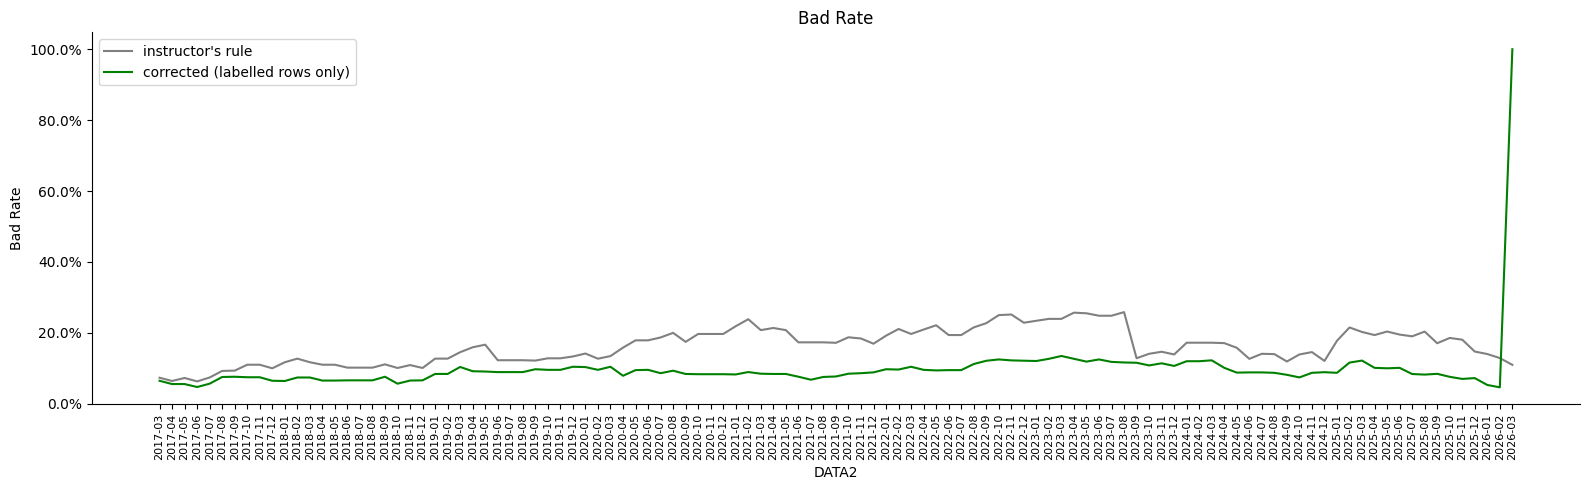

In [27]:
lab = df['modelling_sample']
graph = (df[lab].query('DATA>=201703')
           .groupby('DATA2')
           .agg(n=('target', 'size'), bad=('target', 'sum'))
           .reset_index())
graph['bad_rate'] = graph['bad'] / graph['n']

course = (df.query('DATA>=201703')
            .groupby('DATA2')['target_course'].mean()
            .rename('bad_rate_course').reset_index())
graph = graph.merge(course, on='DATA2', how='left')

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
sns.lineplot(x='DATA2', y='bad_rate_course', data=graph, color='grey',
             label="instructor's rule", ax=ax)
sns.lineplot(x='DATA2', y='bad_rate', data=graph, color='green',
             label='corrected (labelled rows only)', ax=ax)
ax.set_title('Bad Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.1%}'))
ax.set_ylabel('Bad Rate')
plt.xticks(rotation=90, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

## Explanatory Variables: CAMELS

Accounts used (Session 5, slide 14):

- **C**: `BIS`
- **A**: `31000000` classification of the credit portfolio; risk levels D-H
  (`31500005`, `31600008`, `31700001`, `31800004`, `31900007`); `CRWA`
- **M**: `73000006`, `83000003` over `10000007`, `20000004`
- **E**: `70000009`, `80000006` over `60000002`
- **L**: `11000006` over `41000007`

All six are constructed exactly as the instructor writes them. Which of them may enter the model is
decided in notebook 03, where `C01` and `A02` are excluded for the reasons in
`CHANGES_AND_WHY.md`, change S1.

### Capital

The instructor assigns the **raw quarterly** `BIS`, not the interpolated `BIS_linear` that Session 4
just spent its whole missing-data section building, so `C01` is missing wherever the quarter wasn't a
reporting month. Kept as written; see the coverage table below.

In [28]:
df['C01'] = df['BIS']

### Asset quality

In [29]:
df['num_A01'] = df[['31500005', '31600008', '31700001', '31800004', '31900007']].sum(
    axis=1, skipna=True, min_count=1)


def A01(row):
    if (row['31000000'] == 0) | (pd.isnull(row['31000000']) == True):
        return np.nan
    else:
        return row['num_A01'] / row['31000000']


df['A01'] = df[['num_A01', '31000000']].apply(A01, axis=1)


def A02(row):
    if (row['31000000'] == 0) | (pd.isnull(row['31000000']) == True):
        return np.nan
    else:
        return row['CRWA_linear'] / row['31000000']


df['A02'] = df[['CRWA_linear', '31000000']].apply(A02, axis=1)

### Management: Non-Operating Result

In [30]:
df['num_M01'] = df[['73000006', '83000003']].sum(axis=1, skipna=True, min_count=1)  # net interest income
df['den_M01'] = df[['10000007', '20000004']].sum(axis=1, skipna=True, min_count=1)  # total assets


def M01(row):
    if (row['den_M01'] == 0) | (pd.isnull(row['den_M01']) == True):
        return np.nan
    else:
        return row['num_M01'] / row['den_M01']


df['M01'] = df[['den_M01', 'num_M01']].apply(M01, axis=1)

### Earnings: Return on Equity

In [31]:
df['num_E01'] = df[['70000009', '80000006']].sum(axis=1, skipna=True, min_count=1)  # net income
df['den_E01'] = df['60000002']                                                      # equity


def E01(row):
    if (row['den_E01'] == 0) | (pd.isnull(row['den_E01']) == True):
        return np.nan
    else:
        return row['num_E01'] / row['den_E01']


df['E01'] = df[['num_E01', 'den_E01']].apply(E01, axis=1)

### Liquidity: Cash / Deposits

In [32]:
def L01(row):
    if (row['41000007'] == 0) | (pd.isnull(row['41000007']) == True):
        return np.nan
    else:
        return row['11000006'] / row['41000007']


df['L01'] = df[['11000006', '41000007']].apply(L01, axis=1)

**CHECK**: coverage of each CAMELS variable on the labelled sample, by year.

This table is what fixes the sample split in notebook 03. `A01` and `M01` die at the COSIF 1.0/1.5
break because the crosswalk has **no** COSIF 1.5 counterpart for `31500005`, `31800004`, `31900007`,
`73000006` or `83000003`. That's a gap in `map_cosif_final.xlsx` itself rather than a download
problem, so no additional COSIF source can repair it. `A02` dies at 202306, where IF.Data stops
publishing `CRWA`.

In [33]:
camels = ['C01', 'A01', 'A02', 'M01', 'E01', 'L01']
lab = df['modelling_sample']

by_year = df[lab].copy()
by_year['Y'] = by_year['DATA'] // 100
coverage = by_year.groupby('Y')[camels].apply(lambda g: g.notna().mean())
coverage['labelled'] = by_year.groupby('Y').size()
coverage['bad'] = by_year.groupby('Y')['target'].sum().astype(int)

print("Non-missing share of each variable on labelled rows, by year:")
print(coverage.assign(**{c: coverage[c].map('{:.0%}'.format) for c in camels}).to_string())

Non-missing share of each variable on labelled rows, by year:
      C01  A01  A02  M01   E01  L01  labelled  bad
Y                                                 
2017  33%  78%  69%  82%  100%  81%      1286   83
2018  33%  77%  84%  84%  100%  83%      1281   86
2019  33%  77%  83%  82%  100%  80%      1333  124
2020  33%  75%  83%  80%  100%  81%      1404  127
2021  32%  76%  83%  79%  100%  87%      1419  116
2022  31%  73%  77%  81%  100%  93%      1469  158
2023  31%  71%  34%  79%  100%  92%      1737  207
2024  33%  71%   0%  79%  100%  93%      1776  170
2025  33%   0%   0%   0%  100%  92%      1870  171
2026   2%   0%   0%   0%  100%  93%       308   21


Average cash / deposits ratio over time. Session 5, slide 16 calls this the Current Ratio, but
`L01` has no current-liabilities denominator, so we use the accurate name here. See
`CHANGES_AND_WHY.md`.

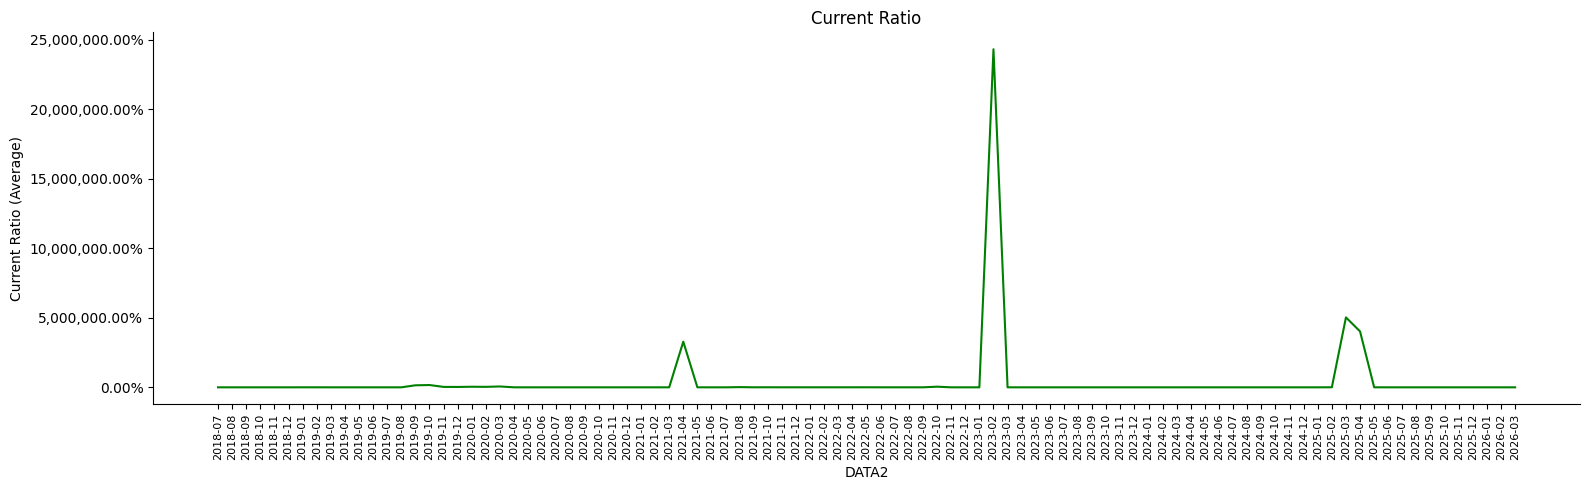

In [34]:
graph = df.query('DATA>=201807').groupby(['DATA2'])['L01'].mean().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
sns.lineplot(x='DATA2', y='L01', data=graph, color='green', ax=ax)
ax.set_title('Current Ratio')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2%}'))
ax.set_ylabel('Current Ratio (Average)')
plt.xticks(rotation=90, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

Export the variable panel for notebook 03.

The instructor also writes `df_var.xlsx` (cell 69). At this panel's size that's a multi-minute
openpyxl write producing a file nothing downstream reads, so it's off by default.

In [35]:
WRITE_EXCEL = False

# Notebook 03 keys on `ID`; writing it here means it does not need to know which panel was built.
df['ID'] = df[ID_COL]
df['PANEL'] = PANEL

df.to_parquet(dir_outputs / 'df_var.parquet')
print(f"Saved df_var.parquet - {df.shape[0]:,} rows x {df.shape[1]} columns")

if WRITE_EXCEL:
    df.to_excel(dir_outputs / 'df_var.xlsx')
    print("Saved df_var.xlsx")

Saved df_var.parquet - 14,566 rows x 312 columns
